# Neighbourhood Characteristics and House Prices

This analysis explores which of crime, deprivation and transport accessibility is most strongly associated with house prices across London neighbourhoods at LSOA level?

The analysis uses the cleaned dataset created in `data_preparation.ipynb`. It begins with exploratory analysis of the main variables before examining their individual relationships with house prices and, finally, evaluating them together using multiple regression.

### 1. Load and Inspect the Prepared Dataset

The prepared dataset is loaded and briefly checked to confirm its dimensions, data types, missing values and duplicate LSOA records before beginning the analysis.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
import statsmodels.api as sm
import statsmodels.formula.api as smf

DATA_PATH = Path("data/final_df.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Duplicate LSOAs:", df["LSOA11CD"].duplicated().sum())
print("Missing values:", df.isna().sum().sum())
print(df.dtypes)
df.head()

Shape: (4746, 27)
Duplicate LSOAs: 0
Missing values: 0
Local Authority Code                        str
Local Authority Name                        str
LSOA11CD                                    str
LSOA Name                                   str
Median House Price 2022                   int64
Arson and Criminal Damage               float64
Burglary                                float64
Drug Offences                           float64
Miscellaneous Crimes Against Society    float64
Possession of Weapons                   float64
Public Order Offences                   float64
Robbery                                 float64
Theft                                   float64
Vehicle Offences                        float64
Violence Against the Person             float64
Total Crime 2022                        float64
IMD Score                               float64
Income Deprivation Score                float64
Employment Deprivation Score            float64
Education Deprivation Score      

,Local Authority Code,Local Authority Name,LSOA11CD,LSOA Name,Median House Price 2022,Arson and Criminal Damage,Burglary,Drug Offences,Miscellaneous Crimes Against Society,Possession of Weapons,...,Income Deprivation Score,Employment Deprivation Score,Education Deprivation Score,Health Deprivation Score,Crime Deprivation Score,Housing Deprivation Score,Living Environment Deprivation Score,Total Population 2015,Average PTAI 2015,PTAL
0,E09000002,Barking and Dagenham,E01000006,Barking and Dagenham 016A,205000,6.0,3.0,17.0,5.0,2.0,...,0.117,0.059,14.798,-0.359,-0.147,45.171,26.888,2040,22.45580,5
1,E09000002,Barking and Dagenham,E01000007,Barking and Dagenham 015A,350000,23.0,9.0,72.0,5.0,9.0,...,0.207,0.107,11.385,-0.027,0.846,50.420,25.995,2101,33.30230,6a
2,E09000002,Barking and Dagenham,E01000008,Barking and Dagenham 015B,190000,14.0,14.0,27.0,3.0,5.0,...,0.265,0.151,25.506,0.250,0.353,45.413,30.233,1566,7.39059,2
3,E09000002,Barking and Dagenham,E01000009,Barking and Dagenham 016B,360000,22.0,5.0,58.0,2.0,2.0,...,0.187,0.109,15.713,0.454,0.895,48.119,28.601,1775,38.36410,6a
4,E09000002,Barking and Dagenham,E01000010,Barking and Dagenham 015C,194000,71.0,48.0,162.0,11.0,10.0,...,0.169,0.073,11.762,-0.002,1.214,50.580,47.932,3195,32.28600,6a


### 2. Exploratory Data Analysis

Before examining individual relationships, the distributions of the main variables are explored to understand their central tendency, variability, skewness and potential outliers.

The initial EDA focuses on median house price, total crime, overall deprivation (IMD) and public transport accessibility (PTAI).

In [2]:
main_cols = [
    "Median House Price 2022",
    "Total Crime 2022",
    "IMD Score",
    "Average PTAI 2015"
]

summary = df[main_cols].describe().T
summary["median"] = df[main_cols].median()
summary["skewness"] = df[main_cols].skew()
summary = summary[["count", "mean", "median", "std", "min", "max", "skewness"]]
summary.round(2)

,count,mean,median,std,min,max,skewness
Median House Price 2022,4746.0,617638.82,520000.00,396233.02,147500.00,6425000.00,5.24
Total Crime 2022,4746.0,167.82,115.00,301.25,2.00,9206.00,17.51
IMD Score,4746.0,21.20,20.09,10.68,2.33,59.01,0.38
Average PTAI 2015,4746.0,13.23,9.47,12.32,0.19,121.89,2.92


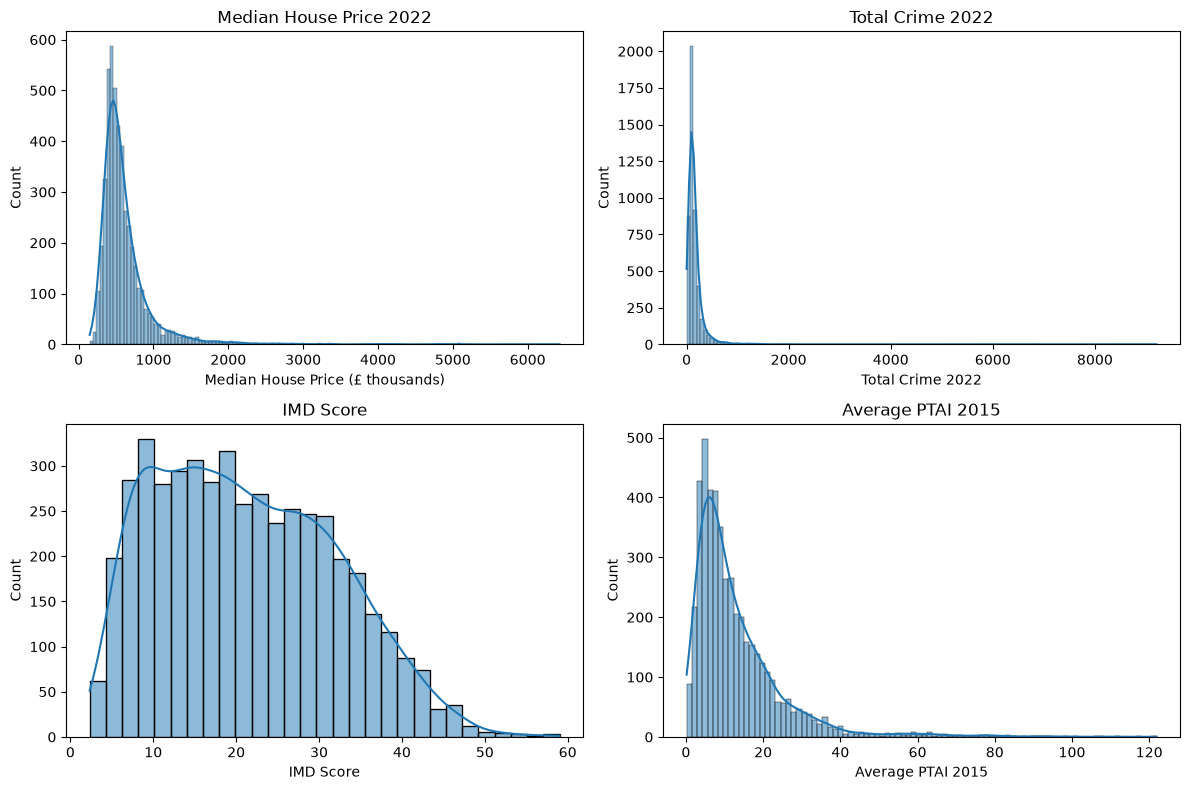

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), main_cols):
    if col == "Median House Price 2022":
        sns.histplot(df[col] / 1000, kde=True, ax=ax)
        ax.set_xlabel("Median House Price (£ thousands)")
    else:
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_xlabel(col)
    ax.set_title(col)

plt.tight_layout()
plt.show()

The distributions show clear differences between the four main variables. Median house prices are strongly right-skewed (skewness = 5.24), reflecting a relatively small number of extremely expensive neighbourhoods. Total crime is even more strongly right-skewed (17.51), with a small number of LSOAs recording exceptionally high crime counts.

Public transport accessibility is also positively skewed (2.92), while the IMD score is much more evenly distributed (skewness = 0.38).

The extreme observations are not automatically removed, as they may represent genuine characteristics of particular London neighbourhoods. Their influence will be examined further during the relationship and regression analyses.

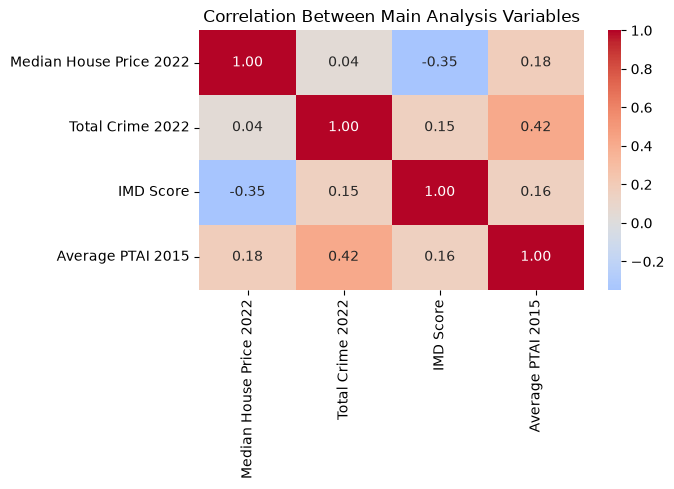

In [4]:
correlation = df[main_cols].corr()
correlation.round(3)

plt.figure(figsize=(7, 5))

sns.heatmap(correlation,annot=True,fmt=".2f",cmap="coolwarm",center=0)

plt.title("Correlation Between Main Analysis Variables")
plt.tight_layout()
plt.show()

A correlation matrix is used to provide an initial overview of the linear relationships between median house prices and the three main neighbourhood characteristics: crime, deprivation and public transport accessibility.

The initial correlation analysis shows that deprivation has the strongest relationship with house prices, with a moderate negative correlation (`r = -0.35`). Public transport accessibility has a weak positive correlation with house prices (`r = 0.18`), while total crime shows almost no linear relationship with house prices (`r = 0.04`). Crime and public transport accessibility are moderately positively correlated (`r = 0.42`). This may reflect the characteristics of highly connected central London areas, where high levels of visitor activity and footfall can also contribute to higher recorded crime counts.

These relationships will be investigated in more detail in the following sections.

### 3. Crime and House Prices

This section examines whether recorded crime is associated with median house prices across London LSOAs. The initial correlation analysis suggested almost no linear relationship between total crime and house prices, despite the expectation that higher crime may be associated with lower property values.

Because total crime is highly right-skewed and contains several extreme values, both Pearson and Spearman correlations are used. Pearson measures a linear relationship and is more sensitive to extreme observations, while Spearman is based on ranks and is less affected by them.

**3.1 Correlation**

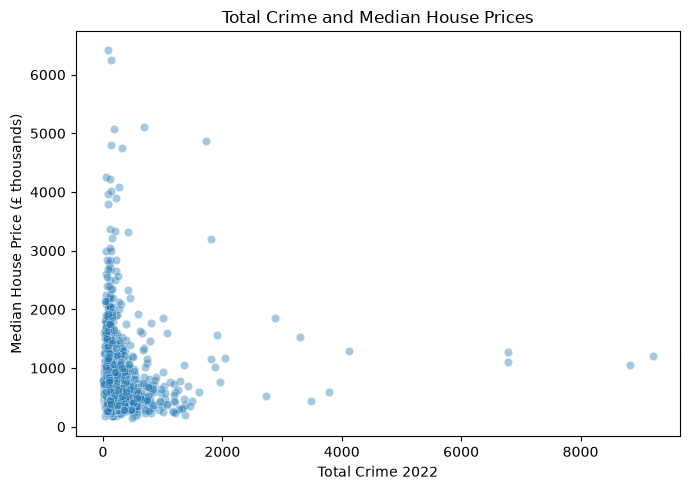

Pearson correlation: r = 0.045, p = 0.00195
Spearman correlation: r = -0.251, p = 5.29e-69


In [5]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="Total Crime 2022", y=df["Median House Price 2022"]/1000, alpha=0.4)

plt.title("Total Crime and Median House Prices")
plt.xlabel("Total Crime 2022")
plt.ylabel("Median House Price (£ thousands)")
plt.tight_layout()
plt.show()

pearson_r, pearson_p = pearsonr(df["Total Crime 2022"], df["Median House Price 2022"])
spearman_r, spearman_p = spearmanr(df["Total Crime 2022"], df["Median House Price 2022"])

print(f"Pearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.3g}")
print(f"Spearman correlation: r = {spearman_r:.3f}, p = {spearman_p:.3g}")

The scatterplot shows that most LSOAs are concentrated at relatively low crime counts, while a small number of areas have exceptionally high recorded crime. 

**Pearson correlation** showed almost no linear relationship between total crime and median house prices (`r = 0.045`, `p = 0.002`). **Spearman correlation** showed a clearer negative association (`r = -0.251`, `p < 0.001`), indicating that neighbourhoods with higher crime generally tend to have lower house prices. The difference between the two measures suggests that extreme crime values may be influencing the Pearson correlation. 

**3.2 Investigating Extreme Crime Values**

The 15 LSOAs with the highest recorded crime totals are examined first to identify which areas are responsible for the most extreme values.

In [6]:
top_crime = df.nlargest(15,"Total Crime 2022")[["Local Authority Name","LSOA Name","Total Crime 2022","Median House Price 2022"]]
top_crime.style.format({"Total Crime 2022": "{:,.0f}","Median House Price 2022": "£{:,.0f}"})

,Local Authority Name,LSOA Name,Total Crime 2022,Median House Price 2022
4531,Westminster,Westminster 018A,"9,206","£1,212,500"
4557,Westminster,Westminster 013B,"8,822","£1,052,500"
4694,Westminster,Westminster 013E,"6,784","£1,270,000"
4695,Westminster,Westminster 013F,"6,784","£1,097,150"
4533,Westminster,Westminster 018C,"4,119","£1,290,000"
4682,Newham,Newham 013G,"3,792","£584,000"
2339,Hillingdon,Hillingdon 031A,"3,484","£435,500"
4532,Westminster,Westminster 018B,"3,301","£1,525,000"
4512,Westminster,Westminster 011B,"2,883","£1,850,861"
2840,Kingston upon Thames,Kingston upon Thames 009C,"2,735","£526,261"


The highest-crime LSOAs are concentrated particularly strongly in Westminster. Several of these neighbourhoods combine exceptionally high crime counts with house prices above £1 million.

This pattern may help explain why the Pearson correlation is close to zero despite the negative Spearman relationship. However, before excluding the borough, all Westminster LSOAs need to be examined.

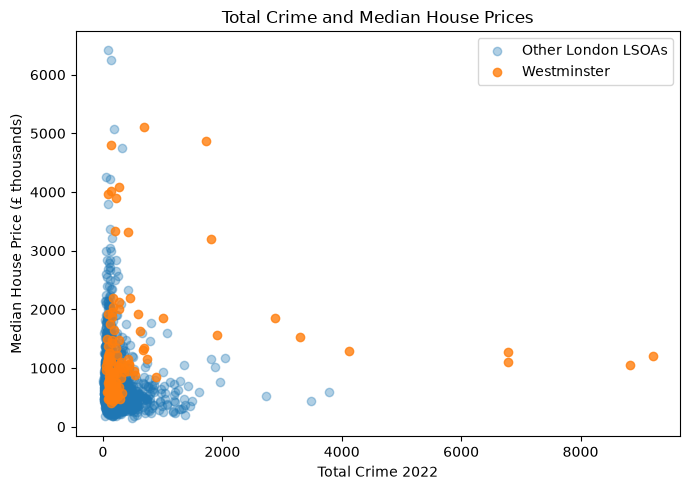

In [7]:
plt.figure(figsize=(7, 5))

westminster = df["Local Authority Name"] == "Westminster"

plt.scatter(
    df.loc[~westminster, "Total Crime 2022"],
    df.loc[~westminster, "Median House Price 2022"] / 1000,
    alpha=0.35,
    label="Other London LSOAs"
)

plt.scatter(
    df.loc[westminster, "Total Crime 2022"],
    df.loc[westminster, "Median House Price 2022"] / 1000,
    alpha=0.8,
    label="Westminster"
)

plt.xlabel("Total Crime 2022")
plt.ylabel("Median House Price (£ thousands)")
plt.title("Total Crime and Median House Prices")
plt.legend()
plt.tight_layout()
plt.show()

Although Westminster contains several of the most extreme high-crime observations, most Westminster LSOAs have crime levels similar to those seen across many other London neighbourhoods. Excluding the entire borough would therefore remove many valid observations.

The next step is to investigate the composition of crime in high-crime areas.

In [8]:
crime_cols = [
    "Arson and Criminal Damage",
    "Burglary",
    "Drug Offences",
    "Miscellaneous Crimes Against Society",
    "Possession of Weapons",
    "Public Order Offences",
    "Robbery",
    "Theft",
    "Vehicle Offences",
    "Violence Against the Person"
]

crime_cutoff = df["Total Crime 2022"].quantile(0.99)
high_crime = df[df["Total Crime 2022"] >= crime_cutoff]
other_areas = df[df["Total Crime 2022"] < crime_cutoff]
high_crime_mix = high_crime[crime_cols].sum() / high_crime["Total Crime 2022"].sum() * 100
other_crime_mix = other_areas[crime_cols].sum() / other_areas["Total Crime 2022"].sum() * 100

crime_mix = pd.DataFrame({
    "Top 1% Crime LSOAs": high_crime_mix,
    "Other LSOAs": other_crime_mix
}).sort_values("Top 1% Crime LSOAs", ascending=False)

crime_mix.round(1)

,Top 1% Crime LSOAs,Other LSOAs
Theft,59.4,23.4
Violence Against the Person,14.4,30.7
Drug Offences,5.3,5.3
Public Order Offences,4.6,7.1
Vehicle Offences,4.4,14.3
Robbery,4.3,3.1
Arson and Criminal Damage,2.7,6.9
Burglary,2.5,7.0
Miscellaneous Crimes Against Society,1.8,1.4
Possession of Weapons,0.6,0.8


The crime profile of the highest-crime LSOAs differs substantially from the rest of London. Theft accounts for 59.4% of recorded crime in the top 1% of LSOAs, compared with 23.4% elsewhere.

This suggests that exceptionally high total-crime counts are disproportionately driven by theft rather than by equally high levels of all crime types. High-footfall commercial or visitor areas may contribute to this pattern, although footfall and tourism are not measured directly in this dataset.

To examine whether high-crime, theft-heavy neighbourhoods are weakening the overall relationship, a sensitivity analysis identifies LSOAs that are simultaneously:

- in the highest 25% for total crime; and
- in the highest 25% for the proportion of crime accounted for by theft.

These LSOAs are temporarily excluded and the correlations are recalculated. This does not imply that the observations are incorrect; the purpose is to assess how strongly this particular group influences the result.

In [9]:
df["Theft Share"] = df["Theft"] / df["Total Crime 2022"]

crime_q75 = df["Total Crime 2022"].quantile(0.75)
theft_q75 = df["Theft Share"].quantile(0.75)
high_crime_high_theft = ((df["Total Crime 2022"] >= crime_q75)& (df["Theft Share"] >= theft_q75))

print(f"Crime 75th percentile: {crime_q75:.0f}")
print(f"Theft-share 75th percentile: {theft_q75:.1%}")
print(f"LSOAs identified: {high_crime_high_theft.sum()}")

df_sensitivity = df[~high_crime_high_theft]
pearson_sens, pearson_p_sens = pearsonr(df_sensitivity["Total Crime 2022"], df_sensitivity["Median House Price 2022"])
spearman_sens, spearman_p_sens = spearmanr(df_sensitivity["Total Crime 2022"],df_sensitivity["Median House Price 2022"])

print(f"Pearson:  r = {pearson_sens:.3f}, p = {pearson_p_sens:.3g}")
print(f"Spearman: r = {spearman_sens:.3f}, p = {spearman_p_sens:.3g}")

Crime 75th percentile: 174
Theft-share 75th percentile: 23.3%
LSOAs identified: 671
Pearson:  r = -0.189, p = 4.87e-34
Spearman: r = -0.356, p = 5.19e-122


After temporarily excluding high-crime, theft-heavy LSOAs, Pearson correlation becomes `-0.189` and Spearman correlation becomes `-0.356`, compared with `0.045` and `-0.251` respectively in the full dataset. This indicates that theft-heavy high-crime areas weaken the overall negative relationship between crime and house prices.

However, these observations represent genuine characteristics of London neighbourhoods rather than data errors. They are therefore retained in the main analysis, while the sensitivity analysis highlights an important limitation of using total crime as a single measure.

**3.3 Do High-Crime Areas Have Lower House Prices?**

To test whether house prices tend to be lower in high-crime neighbourhoods, the highest and lowest quartiles of LSOAs by total crime are compared.

Because house prices are strongly right-skewed, a one-tailed Mann–Whitney U test is used.

- **H₀:** House prices in high-crime areas are not lower than in low-crime areas.
- **H₁:** House prices in high-crime areas are lower than in low-crime areas.

Low-crime median price:  £600,500
High-crime median price: £478,350
U = 468,086.0
p = 1.19e-51


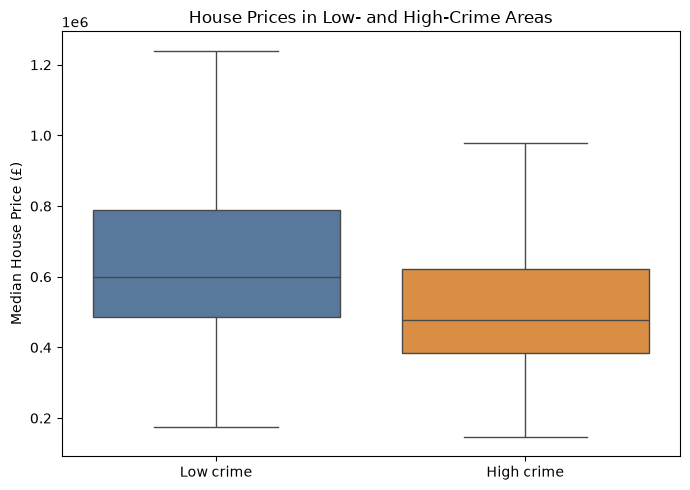

In [10]:
low_cutoff = df["Total Crime 2022"].quantile(0.25)
high_cutoff = df["Total Crime 2022"].quantile(0.75)
low_crime_prices = df.loc[df["Total Crime 2022"] <= low_cutoff,"Median House Price 2022"]
high_crime_prices = df.loc[df["Total Crime 2022"] >= high_cutoff,"Median House Price 2022"]
u_stat, p_value = mannwhitneyu(high_crime_prices,low_crime_prices,alternative="less")

print(f"Low-crime median price:  £{low_crime_prices.median():,.0f}")
print(f"High-crime median price: £{high_crime_prices.median():,.0f}")
print(f"U = {u_stat:,.1f}")
print(f"p = {p_value:.3g}")

crime_groups = pd.DataFrame({
    "House Price": pd.concat([low_crime_prices, high_crime_prices]),
    "Crime Group": (["Low crime"] * len(low_crime_prices)+ ["High crime"] * len(high_crime_prices))
})

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=crime_groups,
    x="Crime Group",
    y="House Price",
    hue="Crime Group",
    order=["Low crime", "High crime"],
    palette={
        "Low crime": "#4C78A8",
        "High crime": "#F28E2B"
    },
    legend=False,
    showfliers=False
)

plt.xlabel("")
plt.ylabel("Median House Price (£)")
plt.title("House Prices in Low- and High-Crime Areas")
plt.tight_layout()
plt.show()

The median house price is **£600,500** in the low-crime group compared with **£478,350** in the high-crime group.

The one-tailed Mann–Whitney U test shows that house prices are significantly lower in high-crime areas (`U = 468,086`, `p < 0.001`). The null hypothesis is therefore rejected.

This supports the Spearman correlation result: although the overall relationship between total crime and house prices is relatively weak, LSOAs with higher crime levels generally tend to have lower house prices.

*Outlier points are hidden from the boxplot for readability but are retained in the statistical test.*

**3.4 Crime Types and House Prices**

Total crime combines offences that may have very different relationships with neighbourhood characteristics. Spearman correlations are therefore calculated separately for each crime category to examine which types of crime have stronger associations with house prices.

Violence Against the Person            -0.412
Arson and Criminal Damage              -0.304
Drug Offences                          -0.285
Miscellaneous Crimes Against Society   -0.259
Public Order Offences                  -0.214
Possession of Weapons                  -0.202
Robbery                                -0.117
Theft                                  -0.067
Vehicle Offences                       -0.019
Burglary                               -0.009
Name: Spearman Correlation, dtype: float64


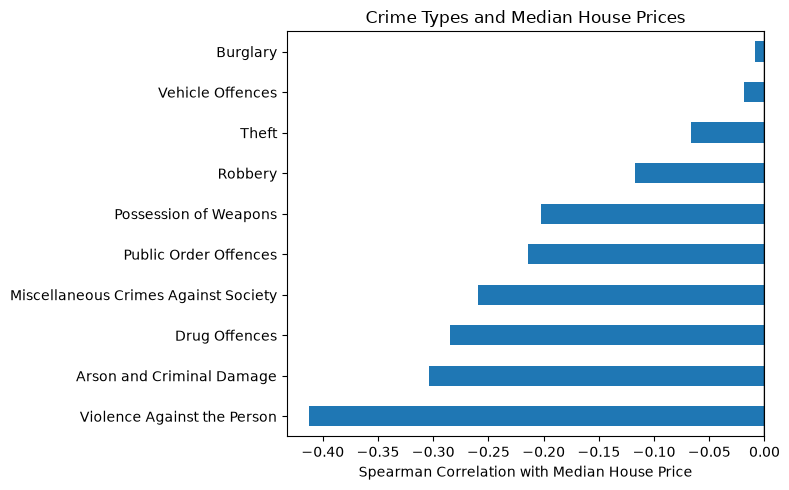

In [11]:
crime_type_corr = {}

for col in crime_cols:
    r, p = spearmanr(df[col],df["Median House Price 2022"])
    crime_type_corr[col] = r

crime_type_corr = pd.Series(crime_type_corr, name="Spearman Correlation").sort_values()
print(crime_type_corr.round(3))

crime_type_corr.plot(kind="barh",figsize=(8, 5))

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Spearman Correlation with Median House Price")
plt.ylabel("")
plt.title("Crime Types and Median House Prices")
plt.tight_layout()
plt.show()

Crime categories show noticeably different relationships with house prices. Violence Against the Person has the strongest negative association (`rₛ = -0.412`), followed by Arson and Criminal Damage (`rₛ = -0.304`) and Drug Offences (`rₛ = -0.285`). In contrast, Theft (`rₛ = -0.067`), Vehicle Offences (`rₛ = -0.019`) and Burglary (`rₛ = -0.009`) show little relationship with house prices.

This suggests that the type of crime provides additional information that is lost when all offences are combined into a single total-crime measure.

**3.5 Crime Analysis Summary**

Overall, higher crime is associated with lower median house prices, although the strength of the relationship depends on how crime is measured. Across all London LSOAs, Spearman correlation shows a weak negative association (`rₛ = -0.251`), while Pearson correlation is close to zero and appears to be strongly influenced by unusual high-crime observations.

Investigation of these observations showed that the highest-crime areas have a distinctly different crime profile, with theft accounting for a much larger proportion of recorded offences. In the sensitivity analysis, excluding LSOAs that were simultaneously in the highest quartile for total crime and theft share strengthened the relationship to `rₛ = -0.356` (Pearson `r = -0.189`). This suggests that high-crime, theft-heavy areas weaken the apparent relationship between total crime and property values. These observations were nevertheless retained because they represent genuine recorded crime rather than data errors.

The hypothesis test also showed a substantial difference between the groups: median house prices were approximately £600,500 in low-crime LSOAs compared with £478,350 in high-crime LSOAs (`p < 0.001`).

Finally, crime type matters. Violence Against the Person showed a considerably stronger negative association with house prices (`rₛ = -0.412`) than Theft (`rₛ = -0.067`), indicating that total crime alone can obscure important differences between types of offence.

Overall, the results suggest that crime is related to house prices, but raw total crime is a relatively limited measure of residential neighbourhood conditions in London.

### 4. Deprivation and House Prices

The Index of Multiple Deprivation (IMD) measures relative deprivation across several dimensions including income, employment, education, health, crime, housing and the living environment. Higher IMD scores indicate greater deprivation.

This section examines whether more deprived London neighbourhoods tend to have lower median house prices.

**4.1 Correlation**

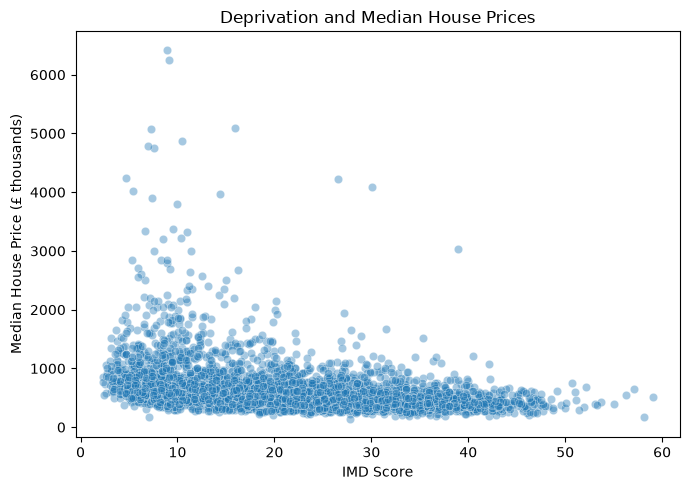

Pearson:  r = -0.346, p = 2.51e-133
Spearman: r = -0.489, p = 5.06e-284


In [12]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="IMD Score",
    y=df["Median House Price 2022"] / 1000,
    alpha=0.4
)

plt.xlabel("IMD Score")
plt.ylabel("Median House Price (£ thousands)")
plt.title("Deprivation and Median House Prices")
plt.tight_layout()
plt.show()

pearson_r, pearson_p = pearsonr(df["IMD Score"], df["Median House Price 2022"])
spearman_r, spearman_p = spearmanr(df["IMD Score"], df["Median House Price 2022"])

print(f"Pearson:  r = {pearson_r:.3f}, p = {pearson_p:.3g}")
print(f"Spearman: r = {spearman_r:.3f}, p = {spearman_p:.3g}")

Pearson correlation shows a moderate negative relationship between deprivation and median house prices (`r = -0.346`, `p < 0.001`). Spearman correlation shows a stronger negative association (`rₛ = -0.489`, `p < 0.001`), indicating that more deprived LSOAs generally tend to have lower house prices.

The stronger Spearman correlation suggests that the relationship is not entirely linear and may also be influenced by the highly skewed distribution of house prices.

**4.2 Do More Deprived Areas Have Lower House Prices?**

To test whether house prices differ between areas with high and low levels of deprivation, LSOAs are divided into the highest and lowest quartiles of IMD Score.

Because house prices are strongly right-skewed, a one-tailed Mann–Whitney U test is used.

- **H₀:** House prices in more deprived areas are not lower than in less deprived areas.
- **H₁:** House prices in more deprived areas are lower than in less deprived areas.

Low-deprivation median price:  £682,500
High-deprivation median price: £425,000
U = 213,916.5
p = 5.38e-190


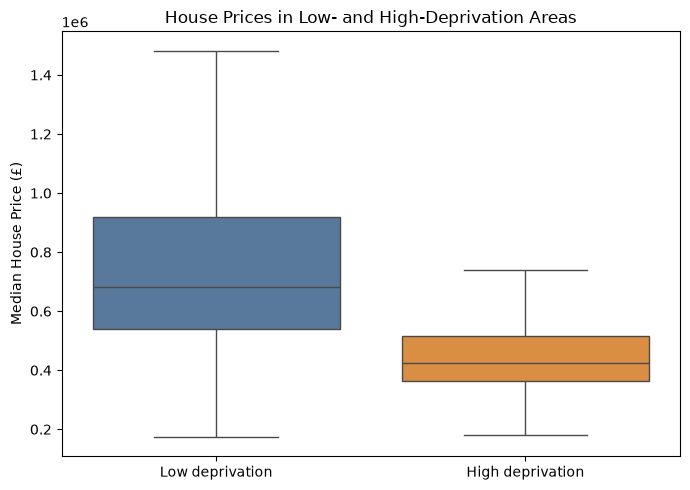

In [13]:
low_cutoff = df["IMD Score"].quantile(0.25)
high_cutoff = df["IMD Score"].quantile(0.75)
low_deprivation_prices = df.loc[df["IMD Score"] <= low_cutoff,"Median House Price 2022"]
high_deprivation_prices = df.loc[df["IMD Score"] >= high_cutoff,"Median House Price 2022"]
u_stat, p_value = mannwhitneyu(high_deprivation_prices,low_deprivation_prices,alternative="less")

print(f"Low-deprivation median price:  £{low_deprivation_prices.median():,.0f}")
print(f"High-deprivation median price: £{high_deprivation_prices.median():,.0f}")
print(f"U = {u_stat:,.1f}")
print(f"p = {p_value:.3g}")

deprivation_groups = pd.DataFrame({
    "House Price": pd.concat([low_deprivation_prices,high_deprivation_prices]),
    "Deprivation Group": ["Low deprivation"]*len(low_deprivation_prices)+["High deprivation"]*len(high_deprivation_prices)
})

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=deprivation_groups,
    x="Deprivation Group",
    y="House Price",
    hue="Deprivation Group",
    order=["Low deprivation", "High deprivation"],
    palette={
        "Low deprivation": "#4C78A8",
        "High deprivation": "#F28E2B"
    },
    legend=False,
    showfliers=False
)

plt.xlabel("")
plt.ylabel("Median House Price (£)")
plt.title("House Prices in Low- and High-Deprivation Areas")
plt.tight_layout()
plt.show()

The median house price is **£682,500** in the low-deprivation group compared with **£425,000** in the high-deprivation group, a difference of approximately **£257,500**.

The one-tailed Mann–Whitney U test shows that house prices are significantly lower in more deprived areas (`U = 213,916.5`, `p < 0.001`). The null hypothesis is therefore rejected.

This supports the correlation analysis and shows a substantial difference in house prices between the least and most deprived quartiles of London LSOAs.

*Outlier points are hidden from the boxplot for readability but are retained in the statistical test.*

**4.3 Deprivation Domains and House Prices**

The overall IMD score combines several different dimensions of deprivation. To examine whether some dimensions are more strongly associated with house prices than others, Spearman correlations are calculated separately for each deprivation domain.

Education Deprivation Score            -0.631
Income Deprivation Score               -0.506
Employment Deprivation Score           -0.467
Health Deprivation Score               -0.434
Housing Deprivation Score              -0.425
Crime Deprivation Score                -0.201
Living Environment Deprivation Score    0.138
Name: Spearman Correlation, dtype: float64


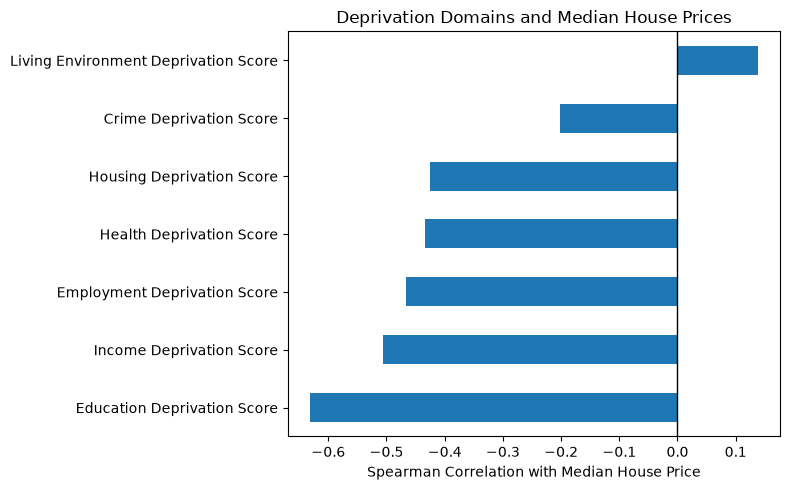

In [14]:
deprivation_cols = [
    "Income Deprivation Score",
    "Employment Deprivation Score",
    "Education Deprivation Score",
    "Health Deprivation Score",
    "Crime Deprivation Score",
    "Housing Deprivation Score",
    "Living Environment Deprivation Score"
]

deprivation_corr = {}

for col in deprivation_cols:
    r, p = spearmanr(df[col], df["Median House Price 2022"])
    deprivation_corr[col] = r

deprivation_corr = pd.Series(deprivation_corr, name="Spearman Correlation").sort_values()
print(deprivation_corr.round(3))

deprivation_corr.plot(kind="barh",figsize=(8, 5))

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Spearman Correlation with Median House Price")
plt.ylabel("")
plt.title("Deprivation Domains and Median House Prices")
plt.tight_layout()
plt.show()

Education deprivation shows the strongest negative association with median house prices (`rₛ = -0.631`), followed by income deprivation (`rₛ = -0.506`) and employment deprivation (`rₛ = -0.467`). This suggests that areas with greater deprivation in education, income and employment generally tend to have substantially lower house prices. Health (`rₛ = -0.434`) and housing deprivation (`rₛ = -0.425`) also show moderate negative associations, while the Crime Deprivation Score has a weaker relationship (`rₛ = -0.201`). Living Environment Deprivation is the only domain with a positive correlation (`rₛ = 0.138`), although the relationship is weak. This indicates that the individual dimensions of deprivation do not all relate to London house prices in the same way.

**4.4 Deprivation Analysis Summary**

Deprivation shows a clear negative association with median house prices. The overall IMD Score has a moderate negative relationship with house prices (`rₛ = -0.489`), indicating that more deprived London neighbourhoods generally tend to have lower property values.

The difference is also substantial when comparing the extremes of the distribution. Median house prices were **£682,500** in the least deprived 25% of LSOAs compared with **£425,000** in the most deprived 25%, a difference of approximately **£257,500**. The Mann–Whitney U test confirmed that house prices are significantly lower in more deprived areas (`p < 0.001`).

The analysis of individual deprivation domains shows that the relationship varies considerably by dimension. Education deprivation has the strongest association with house prices (`rₛ = -0.631`), followed by income and employment deprivation, while living environment deprivation shows only a weak positive relationship.

Overall, deprivation has a considerably clearer relationship with house prices than either total crime or public transport accessibility in the individual analyses. However, these results describe associations and do not show that deprivation itself causes differences in property values.

### 5. Public Transport Accessibility and House Prices

Public transport accessibility is measured using **Average PTAI 2015**, the continuous accessibility index underlying the PTAL categories. Higher values indicate better access to public transport.

This section examines whether London neighbourhoods with better public transport accessibility tend to have higher median house prices.

**5.1 Correlation**

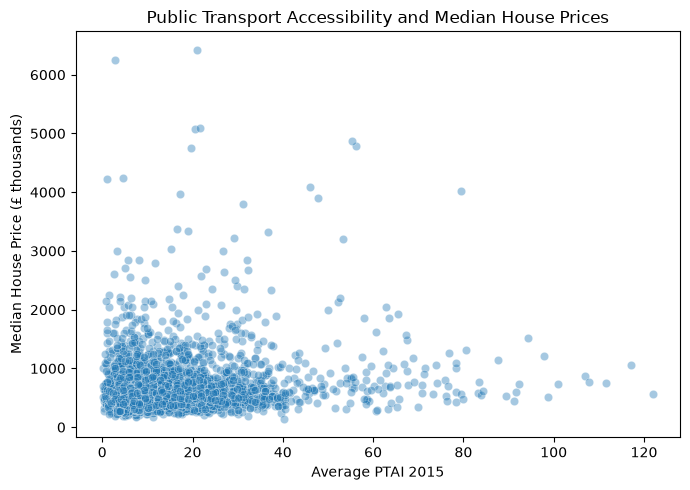

Pearson:  r = 0.179, p = 1.87e-35
Spearman: r = 0.136, p = 6.78e-21


In [15]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Average PTAI 2015",
    y=df["Median House Price 2022"] / 1000,
    alpha=0.4
)

plt.xlabel("Average PTAI 2015")
plt.ylabel("Median House Price (£ thousands)")
plt.title("Public Transport Accessibility and Median House Prices")
plt.tight_layout()
plt.show()

pearson_r, pearson_p = pearsonr(df["Average PTAI 2015"],df["Median House Price 2022"])
spearman_r, spearman_p = spearmanr(df["Average PTAI 2015"],df["Median House Price 2022"])

print(f"Pearson:  r = {pearson_r:.3f}, p = {pearson_p:.3g}")
print(f"Spearman: r = {spearman_r:.3f}, p = {spearman_p:.3g}")

The scatter plot suggests a weak positive relationship between public transport accessibility and median house prices. 

Pearson correlation shows a weak positive relationship between public transport accessibility and median house prices (`r = 0.179`, `p < 0.001`). Spearman correlation is also positive but slightly weaker (`rₛ = 0.136`, `p < 0.001`). This suggests that LSOAs with better public transport accessibility generally tend to have higher house prices, although the relationship is weak.

**5.2 Distribution and Extreme Values**

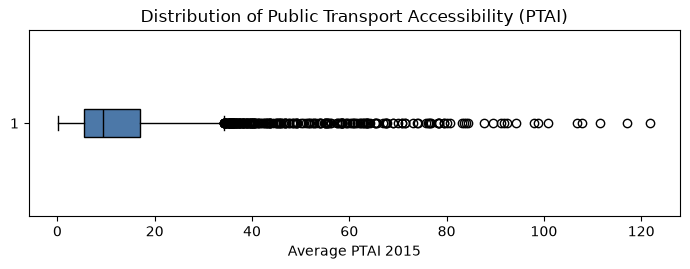

,Local Authority Name,LSOA Name,Average PTAI 2015,PTAL
4581,Southwark,Southwark 034E,121.8870,6b
4579,Lambeth,Lambeth 036E,117.0410,6b
4591,City of London,City of London 001F,111.4790,6b
2887,Lambeth,Lambeth 036D,107.8610,6b
2886,Lambeth,Lambeth 036C,106.8410,6b
4580,Southwark,Southwark 034D,100.9260,6b
3771,Southwark,Southwark 034A,98.7026,6b
4531,Westminster,Westminster 018A,97.9024,6b
4532,Westminster,Westminster 018B,94.2208,6b
3770,Southwark,Southwark 002B,92.3200,6b


In [16]:
plt.figure(figsize=(7, 2.8))

bp = plt.boxplot(df["Average PTAI 2015"],orientation="horizontal",patch_artist=True)
bp["boxes"][0].set_facecolor("#4c78a8") 
bp["medians"][0].set_color("black")
plt.title("Distribution of Public Transport Accessibility (PTAI)")
plt.xlabel("Average PTAI 2015")
plt.tight_layout()
plt.show()

df.nlargest(10,"Average PTAI 2015")[["Local Authority Name", "LSOA Name", "Average PTAI 2015", "PTAL"]]

The boxplot shows a long right tail, with a number of PTAI values beyond the standard 1.5 × IQR threshold. These observations are statistical outliers, but this does not necessarily indicate data errors.

Inspection of the LSOAs with the highest PTAI values shows that they are located in highly accessible central London areas. The extreme values therefore represent genuine differences in public transport accessibility and are retained in the analysis.

**5.3 Do Areas with Better Public Transport Accessibility Have Higher House Prices?**

To test whether house prices differ between areas with high and low public transport accessibility, LSOAs are divided into the highest and lowest quartiles of Average PTAI.

Because house prices are strongly right-skewed, a one-tailed Mann–Whitney U test is used.

- **H₀:** House prices in high-accessibility areas are not higher than in low-accessibility areas.
- **H₁:** House prices in high-accessibility areas are higher than in low-accessibility areas.

Low-accessibility median price:  £500,000
High-accessibility median price: £585,000
U = 849,064.5
p = 2.4e-18


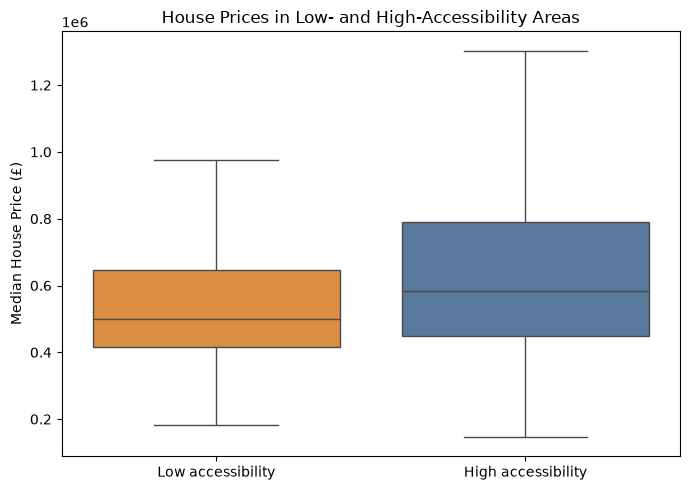

In [17]:
low_cutoff = df["Average PTAI 2015"].quantile(0.25)
high_cutoff = df["Average PTAI 2015"].quantile(0.75)
low_access_prices = df.loc[df["Average PTAI 2015"] <= low_cutoff,"Median House Price 2022"]
high_access_prices = df.loc[df["Average PTAI 2015"] >= high_cutoff,"Median House Price 2022"]
u_stat, p_value = mannwhitneyu(high_access_prices,low_access_prices,alternative="greater")

print(f"Low-accessibility median price:  £{low_access_prices.median():,.0f}")
print(f"High-accessibility median price: £{high_access_prices.median():,.0f}")
print(f"U = {u_stat:,.1f}")
print(f"p = {p_value:.3g}")

access_groups = pd.DataFrame({
    "House Price": pd.concat([low_access_prices,high_access_prices]),
    "Accessibility Group": ["Low accessibility"]*len(low_access_prices)+["High accessibility"]*len(high_access_prices)
})

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=access_groups,
    x="Accessibility Group",
    y="House Price",
    hue="Accessibility Group",
    order=["Low accessibility", "High accessibility"],
    palette={
        "Low accessibility": "#F28E2B",
        "High accessibility": "#4C78A8"
    },
    showfliers=False,
    legend=False
)

plt.xlabel("")
plt.ylabel("Median House Price (£)")
plt.title("House Prices in Low- and High-Accessibility Areas")
plt.tight_layout()
plt.show()

The median house price is **£500,000** in the low-accessibility group compared with **£585,000** in the high-accessibility group.

The one-tailed Mann–Whitney U test shows that house prices are significantly higher in areas with better public transport accessibility (`U = 849,064.5`, `p < 0.001`). The null hypothesis is therefore rejected.

Although the difference between the groups is statistically significant, the relatively weak correlations indicate that transport accessibility alone explains only a limited part of the variation in house prices.

*Outlier points are hidden from the boxplot for readability but are retained in the statistical test.*

**5.4 Public Transport Accessibility Summary**

Public transport accessibility is positively associated with house prices, but the relationship is relatively weak. Both Pearson (`r = 0.179`) and Spearman (`rₛ = 0.136`) correlations indicate that better-connected neighbourhoods generally tend to have higher property values.

The quartile comparison provides further evidence of this pattern: median house prices were approximately **£85,000 higher** in the most accessible 25% of LSOAs than in the least accessible 25%, and the difference was statistically significant (`p < 0.001`).

Overall, public transport accessibility is positively associated with house prices, but the relationship is relatively weak, suggesting that accessibility alone has limited explanatory power.

### 6. Multiple Regression

The previous sections examined crime, deprivation and public transport accessibility separately. Multiple regression is now used to examine how these neighbourhood characteristics are associated with house prices when considered together.

House prices, total crime and public transport accessibility are strongly right-skewed, so logarithmic transformations are applied to these variables before modelling. IMD Score is retained in its original form because its distribution is relatively balanced.

The model uses the full dataset, including the high-crime, theft-heavy LSOAs identified earlier, because these observations represent genuine neighbourhood characteristics rather than data errors.

**6.1 Preparing Variables**

House prices, total crime and PTAI are strongly right-skewed. Log transformations are therefore applied to reduce the influence of extreme values and make their relationships easier to model on a linear scale. IMD Score is retained in its original form because its distribution is relatively balanced.

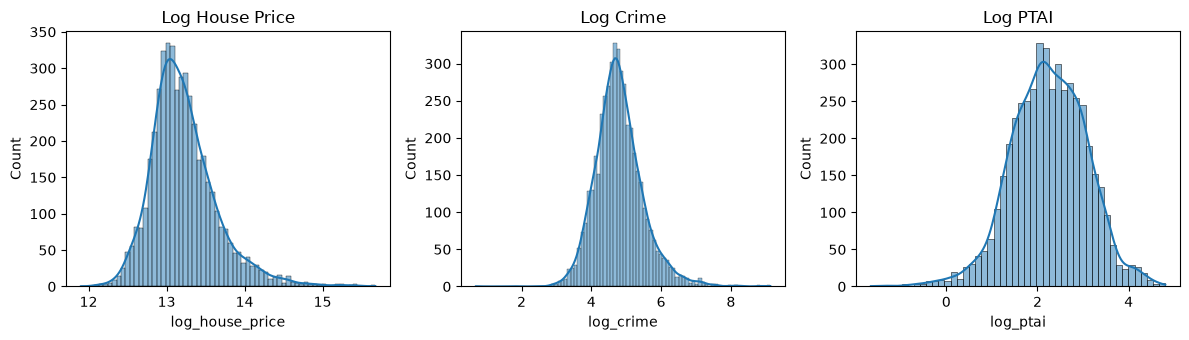

In [18]:
reg_df = pd.DataFrame({
    "log_house_price": np.log(df["Median House Price 2022"]),
    "log_crime": np.log(df["Total Crime 2022"]),
    "imd_score": df["IMD Score"],
    "log_ptai": np.log(df["Average PTAI 2015"])
})

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

sns.histplot(reg_df["log_house_price"], kde=True, ax=axes[0])
axes[0].set_title("Log House Price")

sns.histplot(reg_df["log_crime"], kde=True, ax=axes[1])
axes[1].set_title("Log Crime")

sns.histplot(reg_df["log_ptai"], kde=True, ax=axes[2])
axes[2].set_title("Log PTAI")

plt.tight_layout()
plt.show()

The transformations substantially reduce the strong right-skew in all three variables. The transformed variables are more compact and closer to symmetric distributions, making them more suitable for linear regression. The assumptions of the regression model will be assessed separately using residual diagnostics after the model is fitted.

**6.2 Multiple Regression Model**

A multiple linear regression model is fitted to examine the associations between crime, deprivation, public transport accessibility and house prices simultaneously.

Using the transformed variables, the model is:

**Log House Price ~ Log Crime + IMD Score + Log PTAI**

Including all three neighbourhood characteristics allows each coefficient to represent its association with house prices while holding the other two variables constant.

In [19]:
model = smf.ols("log_house_price ~ log_crime + imd_score + log_ptai", data=reg_df).fit()
coef_table = pd.DataFrame({
    "Coefficient": model.params,
    "CI Lower": model.conf_int()[0],
    "CI Upper": model.conf_int()[1],
    "p-value": model.pvalues
}).drop("Intercept")

print(coef_table.round(4))
print(f"R²: {model.rsquared:.3f}")
print(f"Adjusted R²: {model.rsquared_adj:.3f}")
print(f"Model p-value: {model.f_pvalue:.3g}")


           Coefficient  CI Lower  CI Upper  p-value
log_crime      -0.0266   -0.0454   -0.0078   0.0056
imd_score      -0.0196   -0.0207   -0.0185   0.0000
log_ptai        0.1376    0.1233    0.1518   0.0000
R²: 0.266
Adjusted R²: 0.265
Model p-value: 3.33e-317


The model is statistically significant (`p < 0.001`) and explains approximately **26.6% of the variation in log house prices** (`R² = 0.266`, adjusted `R² = 0.265`).

Holding the other neighbourhood characteristics constant:

- a 1% increase in total crime is associated with approximately a **0.027% decrease** in house price (`p = 0.006`);
- a one-point increase in IMD Score is associated with approximately a **1.9% decrease** in house price (`p < 0.001`);
- a 1% increase in PTAI is associated with approximately a **0.138% increase** in house price (`p < 0.001`).

The initial OLS results indicate that all three predictors are statistically significant. However, the reliability of the standard errors, confidence intervals and p-values depends on the regression assumptions, which are examined in the next section.

Because the predictors are measured on different scales, their raw regression coefficients cannot be compared directly to determine which has the strongest association with house prices.

To make the effects comparable, standardised regression coefficients are calculated. These express each relationship in standard-deviation units while holding the other predictors constant.

In [20]:
predictors = ["log_crime", "imd_score", "log_ptai"]

standardised_coefficients = model.params[predictors]*reg_df[predictors].std()/reg_df["log_house_price"].std()
standardised_coefficients

log_crime   -0.043222
imd_score   -0.489761
log_ptai     0.266368
dtype: float64

The standardised coefficients show that **deprivation has the strongest adjusted association with house prices** (`β = -0.490`), followed by public transport accessibility (`β = 0.266`). Crime has a much smaller adjusted association (`β = -0.043`).

This reinforces the earlier finding that deprivation has the clearest relationship with house prices. It also shows that, after accounting for deprivation and transport accessibility, total crime contributes relatively little to differences in house prices within this model.

**6.3 Model Diagnostics**

Linear regression relies on several assumptions about the model and its errors. Residuals — the differences between the observed and predicted log house prices — are examined to assess whether the main regression assumptions are reasonably satisfied.

The **residuals-versus-fitted plot** is used to check whether the relationships are approximately linear and whether the residuals have a roughly constant spread across predicted values. The **Q–Q plot** examines whether the residuals are approximately normally distributed. Finally, **Variance Inflation Factors (VIF)** are calculated to check whether the predictors are too strongly related to one another, which could make their individual coefficients unreliable.

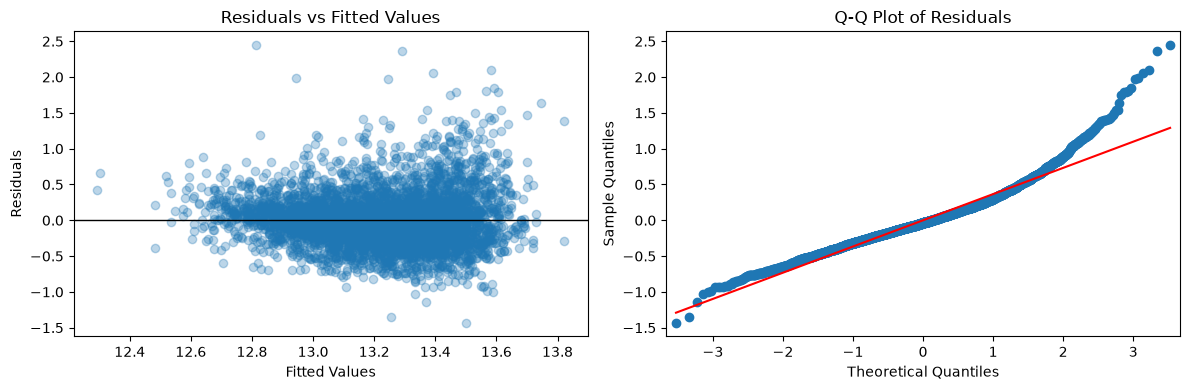

,Variable,VIF
1,log_crime,1.57
2,imd_score,1.29
3,log_ptai,1.28


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(model.fittedvalues,model.resid,alpha=0.3)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted Values")

sm.qqplot(model.resid,line="s",ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(reg_df[["log_crime", "imd_score", "log_ptai"]])

vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif = vif[vif["Variable"] != "const"]
vif.round(2)

The residuals are generally centred around zero and there is no strong curved pattern, suggesting that the linear form of the model is reasonably appropriate. However, the spread of the residuals increases somewhat at higher fitted values, suggesting that the variance of the errors may not be completely constant.

The Q–Q plot follows the reference line reasonably closely through much of the distribution but deviates in the upper tail. This indicates that the residuals are not perfectly normally distributed and that some LSOAs have substantially higher house prices than the model predicts.

The VIF values are low for all three predictors (`1.57` for crime, `1.29` for IMD and `1.28` for PTAI), well below commonly used thresholds for concern. This indicates that multicollinearity is not a problem in the model. Although crime, deprivation and public transport accessibility are related to one another, the relationships are not strong enough to make their regression coefficients unstable.

The increasing spread in the residual plot suggests possible **heteroskedasticity**, meaning that the size of the model errors may vary across fitted values. A Breusch–Pagan test is used to formally assess this. The null hypothesis is that the residual variance is constant; a small p-value provides evidence that this assumption is violated.

In [22]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid,model.model.exog)
print(f"Breusch-Pagan p-value: {bp_test[1]:.3g}")

Breusch-Pagan p-value: 1.97e-33


The Breusch–Pagan test is statistically significant (`p < 0.001`), providing strong evidence that the residual variance is not constant.

Because heteroskedasticity can make conventional OLS standard errors, confidence intervals and p-values unreliable, **HC3 robust standard errors** are used for the final statistical inference. This adjustment does not change the regression coefficients, fitted values or R²; it only adjusts the estimated uncertainty around the coefficients.

In [23]:
robust_model = model.get_robustcov_results(cov_type="HC3")
  
robust_results = pd.DataFrame({
    "Coefficient": model.params[1:],
    "OLS p-value": model.pvalues[1:],
    "HC3 p-value": robust_model.pvalues[1:],
    "HC3 CI Lower": robust_model.conf_int()[1:, 0],
    "HC3 CI Upper": robust_model.conf_int()[1:, 1]
}, index=["log_crime", "imd_score", "log_ptai"])

robust_results.round(4)

,Coefficient,OLS p-value,HC3 p-value,HC3 CI Lower,HC3 CI Upper
log_crime,-0.0266,0.0056,0.0201,-0.0490,-0.0042
imd_score,-0.0196,0.0000,0.0000,-0.0209,-0.0183
log_ptai,0.1376,0.0000,0.0000,0.1217,0.1534


Using HC3 robust standard errors, all three predictors remain statistically significant.

The crime coefficient remains negative (`b = -0.0266`), but its p-value increases from `0.0056` under ordinary OLS to `0.0201` with robust standard errors. Its 95% robust confidence interval (`-0.0490` to `-0.0042`) remains below zero, so the negative association is still statistically significant.

The IMD coefficient remains negative (`b = -0.0196`, `p < 0.001`), while the PTAI coefficient remains positive (`b = 0.1376`, `p < 0.001`). Their conclusions are essentially unchanged after the robust adjustment.

Overall, using robust standard errors does not change the direction or statistical significance of any of the three relationships, although the evidence for the crime association becomes weaker.

**6.4 Multiple Regression Summary**

The multiple regression model explains approximately **26.6% of the variation in log house prices** across London LSOAs (`R² = 0.266`, adjusted `R² = 0.265`).

After accounting for the other neighbourhood characteristics, all three predictors remain statistically significant using HC3 robust standard errors. Higher crime is associated with slightly lower house prices (`b = -0.0266`, `p = 0.020`), higher deprivation is associated with lower house prices (`b = -0.0196`, `p < 0.001`), and better public transport accessibility is associated with higher house prices (`b = 0.1376`, `p < 0.001`).

Because the predictors are measured on different scales, standardised coefficients provide a clearer comparison of their relative associations. **Deprivation has the strongest adjusted association with house prices** (`β = -0.490`), followed by public transport accessibility (`β = 0.266`), while total crime has a much smaller adjusted association (`β = -0.043`).

Model diagnostics show no major evidence of non-linearity or problematic multicollinearity. Unequal residual variance was identified, so HC3 robust standard errors were used for the final statistical inference.

Overall, deprivation shows the clearest adjusted relationship with house prices in this model, while transport accessibility also has a meaningful positive association. Total crime provides much less additional information once the other neighbourhood characteristics are taken into account. However, the model explains only part of the variation in house prices, and the results should be interpreted as associations rather than causal effects.

### 7. Overall Conclusion

This analysis examined how crime, deprivation and public transport accessibility are associated with median house prices across London LSOAs.

Overall, **deprivation shows the clearest relationship with house prices**. This is evident both when deprivation is analysed separately and in the multiple regression, where it has the strongest standardised adjusted association (`β = -0.490`). Public transport accessibility also has a meaningful positive adjusted association (`β = 0.266`), while total crime has a much smaller association once the other neighbourhood characteristics are taken into account (`β = -0.043`).

The multiple regression explains approximately **26.6% of the variation in log house prices**, indicating that these neighbourhood characteristics are relevant but account for only part of the differences in property values across London. Other property, location and neighbourhood factors not included in the analysis are also likely to be important.

These findings describe statistical associations rather than causal effects.

### 8. Limitations

Several limitations should be considered when interpreting the results. The datasets relate to different years: house prices and crime are from 2022, IMD is from 2019, and public transport accessibility is from 2015. The analysis also does not include many other factors that influence house prices, such as property type, size, tenure, school quality or proximity to central London.

Total crime is based on recorded offence counts rather than a resident-adjusted crime rate, so high-footfall commercial or visitor areas may record high crime levels that do not directly reflect the experience of the resident population.

In addition, neighbouring LSOAs may share similar characteristics, so the observations may not be completely independent. Finally, this is an observational cross-sectional analysis, so the relationships identified should be interpreted as associations rather than causal effects.
